In [1]:
import pandas as pd
df=pd.read_csv('salaries.csv')
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [14]:
inputs=df.drop('salary_more_then_100k',axis='columns')
targets=df['salary_more_then_100k']
inputs.head()

,company,job,degree
0,google,sales executive,bachelors
1,google,sales executive,masters
2,google,business manager,bachelors
3,google,business manager,masters
4,google,computer programmer,bachelors


In [13]:
targets.head()

0    0
1    0
2    1
3    1
4    0
Name: salary_more_then_100k, dtype: int64

In [15]:
 from sklearn.preprocessing import LabelEncoder

In [16]:
le_company=LabelEncoder()
le_job=LabelEncoder()
le_degree=LabelEncoder()


In [17]:
inputs['company_n']=le_company.fit_transform(inputs['company'])
inputs['job_n']=le_job.fit_transform(inputs['job'])
inputs['degree_n']=le_degree.fit_transform(inputs['degree'])
inputs.head()

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0


In [18]:
inputs_n=inputs.drop(['company','job','degree'],axis='columns')
inputs_n.head()

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0


In [ ]:
#Split the dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(inputs_n, targets,test_size=0.2)

,company_n,job_n,degree_n
2,2,0,0
9,0,0,1
14,1,1,0
10,1,2,0
6,0,2,1
15,1,1,1
12,1,0,0
4,2,1,0
8,0,0,0
0,2,2,0


In [25]:
from sklearn import tree
model=tree.DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
model.score(x_test,y_test)

0.75

In [27]:
from sklearn.metrics import confusion_matrix
y_predicted=model.predict(x_test)
cm=confusion_matrix(y_test,y_predicted)
cm

array([[1, 1],
       [0, 2]])

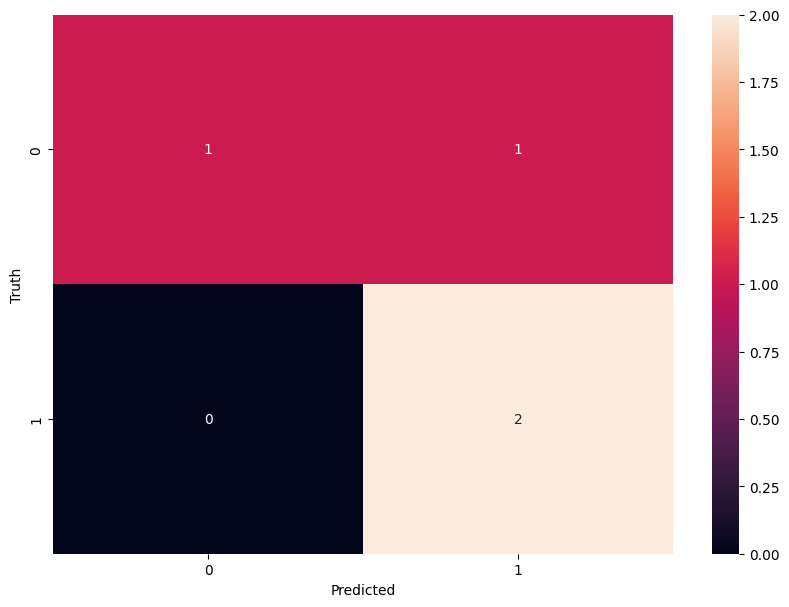

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()
